# Intro

This notebook introduces the behavioral dataset and walks through how the data is cleaned before any analysis is performed. Here, the focus is on the subject's pushes and less so on continuous variables, such as gaze and position.

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import logging
import os

import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

pd.options.mode.copy_on_write = True
from foraging.plotting import bp

# Filter out annoying matplotlib logs
mlogger = logging.getLogger('matplotlib')
mlogger.setLevel(logging.WARNING)

EXPERIMENT_DIR = '../data/experiments'
ANALYSIS_DIR = '../data/analysis'
FIGURES_DIR = '../figures'
SEED = 42

# Load Data

The experiment data consists of multiple matfiles corresponding to the data for different subjects. Each matfile contains that subject's push, eye tracking (if available), and position (if available) data organized by blocks and sessions. Each block corresponds to a set of experiment parameters, notably the schedule of each box, the stimulus reliability kappa, and the stimulus type. A hierarchical overview of a given matfile is as follows:

+--- subject  
&nbsp;&nbsp;&nbsp;&nbsp; |___ session  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |___ block (kappa, stimulus type, schedules)  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |___ push times  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |___ reward outcomes  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |___ push times

For human data, each session is a subject. Otherwise noted, subjects underwent multiple sessions, one session per day, and each contain multiple blocks with different experiment parameters per block.
Refer to `docs\info.docx` for more details.

Here is a DataFrame showing a subset of the data. Refer to the docstring of `make_df` for more information about the contents of the DataFrame.

In [3]:
from foraging.utils.data import make_df, display_df

df = make_df(EXPERIMENT_DIR)
display_df(df, ["box", "push times", "reward outcomes"]);

|                                                            | box   |   push times | reward outcomes   |
|:-----------------------------------------------------------|:------|-------------:|:------------------|
| ('dylan', 20211206, 1, 1, 'probability', 1, nan, 1.0, 'M') | fast  |       26.75  | True              |
| ('dylan', 20211206, 1, 2, 'probability', 1, nan, 1.0, 'M') | fast  |       31.159 | True              |
| ('dylan', 20211206, 1, 3, 'probability', 1, nan, 1.0, 'M') | fast  |       33.338 | True              |
| ('dylan', 20211206, 1, 4, 'probability', 1, nan, 1.0, 'M') | fast  |       35.537 | False             |
| ('dylan', 20211206, 1, 5, 'probability', 1, nan, 1.0, 'M') | fast  |       37.476 | False             |

## Data Overview
A quick overview of the summary statistics:

In [4]:
print("schedules experienced by each subject")
print(df.groupby('subject')['schedule'].unique());

schedules experienced by each subject
subject
dylan                                  [15.0, 35.0, 21.0]
humans                                  [14.0, 21.0, 7.0]
marco                            [35.0, 15.0, 21.0, 30.0]
viktor    [15.0, 21.0, 35.0, 28.0, 7.0, 14.0, 20.0, 80.0]
Name: schedule, dtype: object


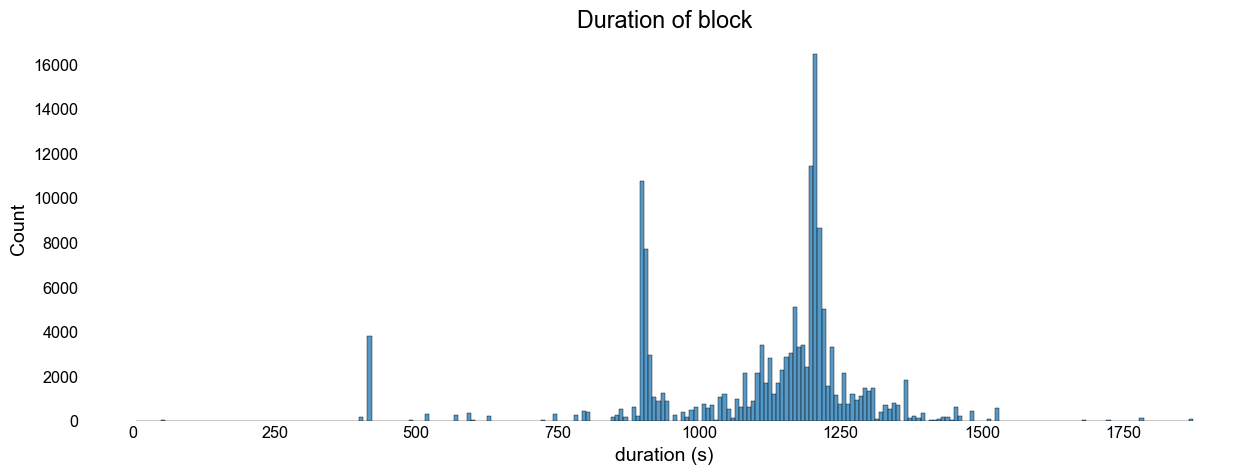

In [5]:
sns.histplot(df, x='duration')
plt.title("Duration of block")
plt.xlabel("duration (s)");

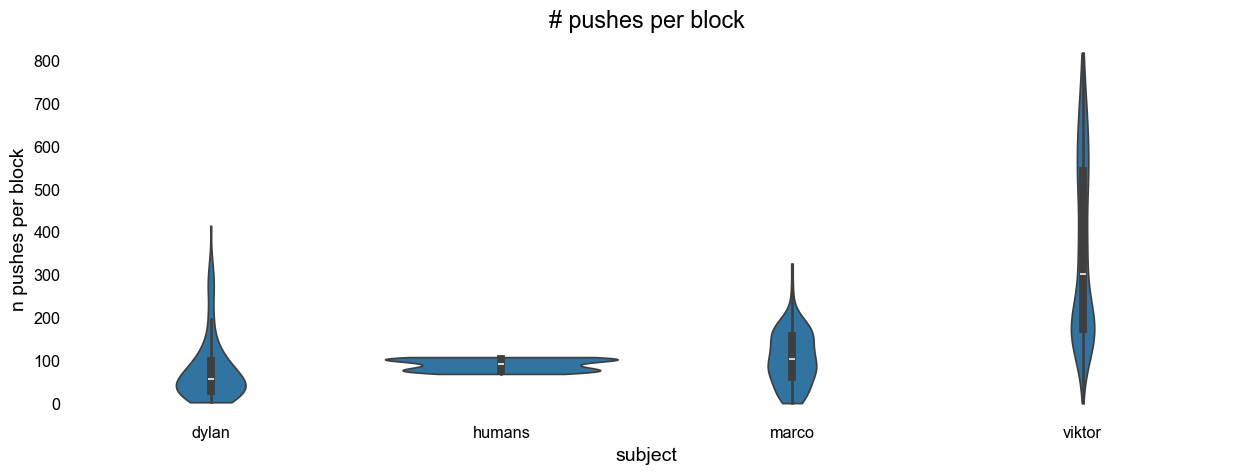

In [6]:
block_summary = df.groupby(['subject', 'session', 'block']).size().reset_index(name='n pushes per block')
sns.violinplot(block_summary, x='subject', y='n pushes per block', cut=0)
plt.title("# pushes per block");

Here is a bird's eye view of one subject's behavioral data over the course of the entire experiment. Each row is a session of consecutive blocks. Each block's pushes are displayed as a raster plot over the duration of that block, and the pushes at each box position are stacked on top of each other (top to bottom is 3, 2, 1). Finally, pushes are colored by box schedule, so we can see how the schedules are assigned to each box over consecutive blocks.

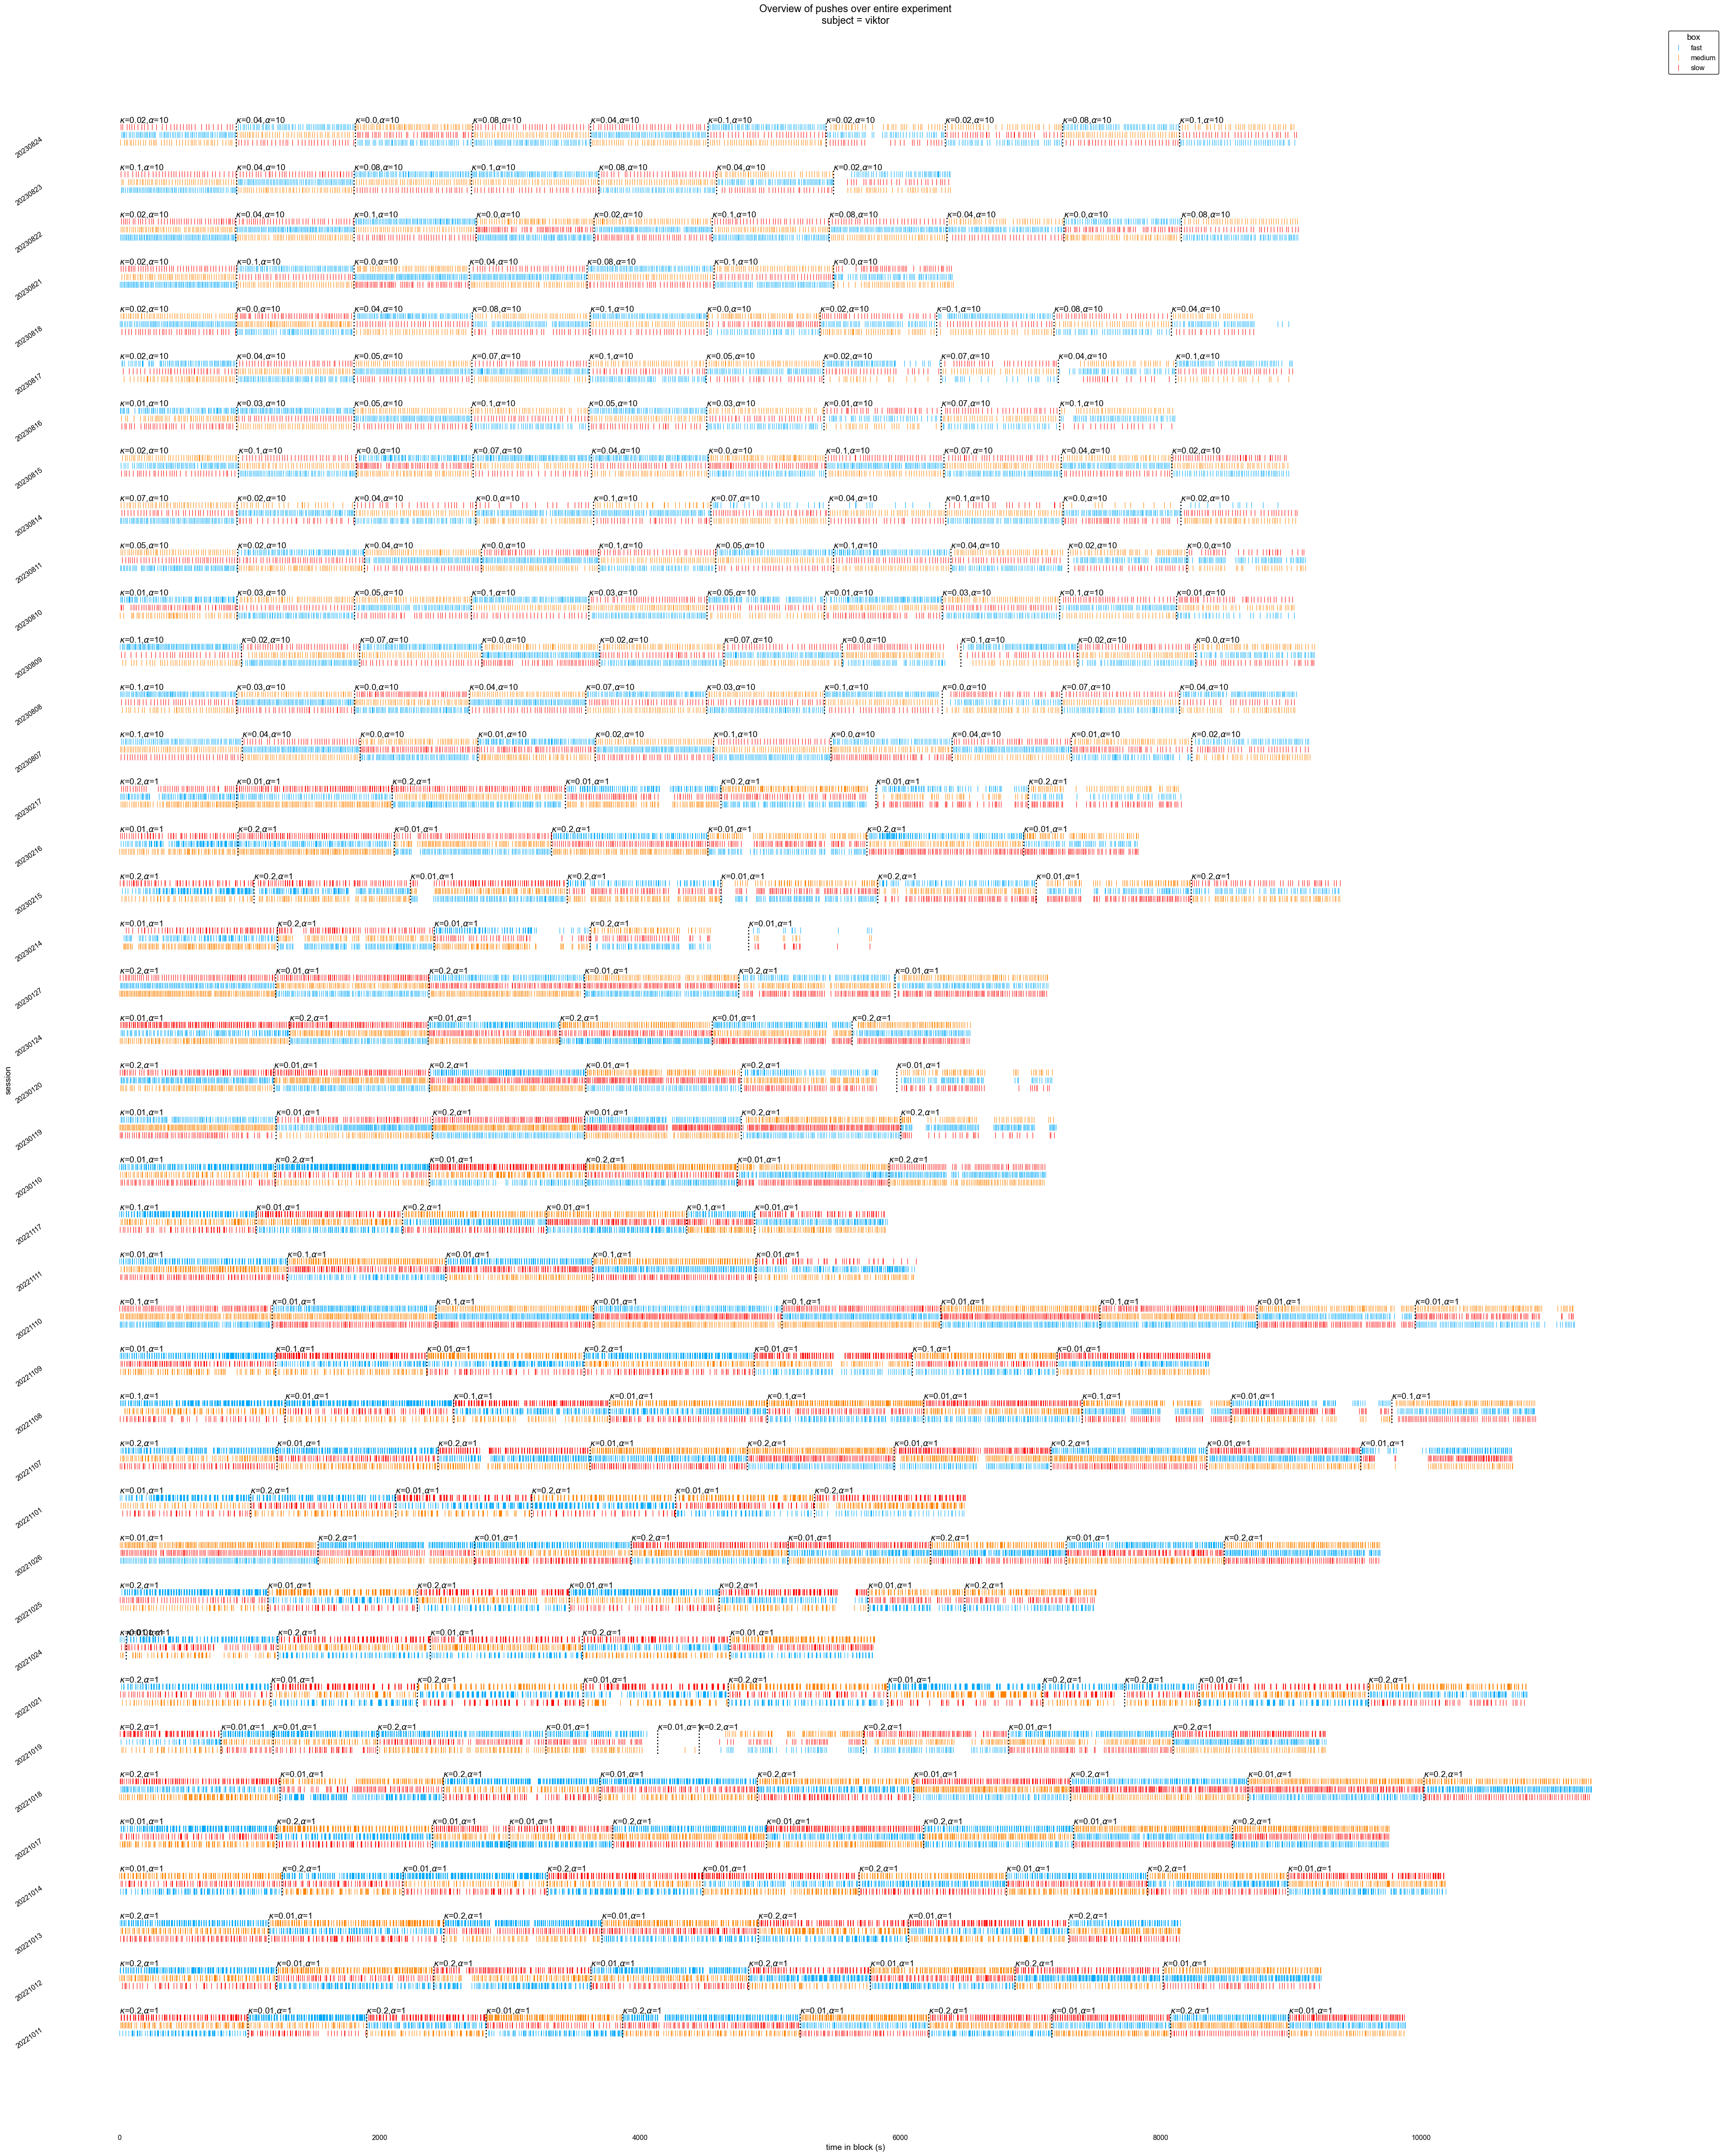

In [33]:
from foraging.plotting.behavior import plot_experiment_overview

conds = dict(subject='viktor')
plot_experiment_overview(df, conds=conds, title_prefix='Overview of pushes over entire experiment', annotate_block=True,
                         fig_kwargs=dict(figsize=(40, 50)));

# Analyze Outliers

Before we get to the fun stuff of analyzing behavior, it is worth taking pains to clean the data by filtering out behavior that seems "off-task". This may seem counterproductive to the goal of analyzing free behavior, but there is a trade-off between the goals of modeling as much of the behavior as possible and having a simple model of a subset of "interesting" behavior. The goal of this notebook is to design a rudimentary exclusion criteria to isolate this subset of outliers. Intuitively, long bouts of time when the subject is not pushing should be indicative of off-task or "lapse" behavior. This is a vague criterion that we will refine by exploring the distribution of consecutive push intervals, the times between consecutive pushes.

Here, each subject's push intervals are shown on a logscale. The individual circles are outliers that would show up on a boxplot of the data, defined as all datapoints lying outside of 1.5*IQR (inter-quartile range) from the first and third quartile (in the original data space, not log).

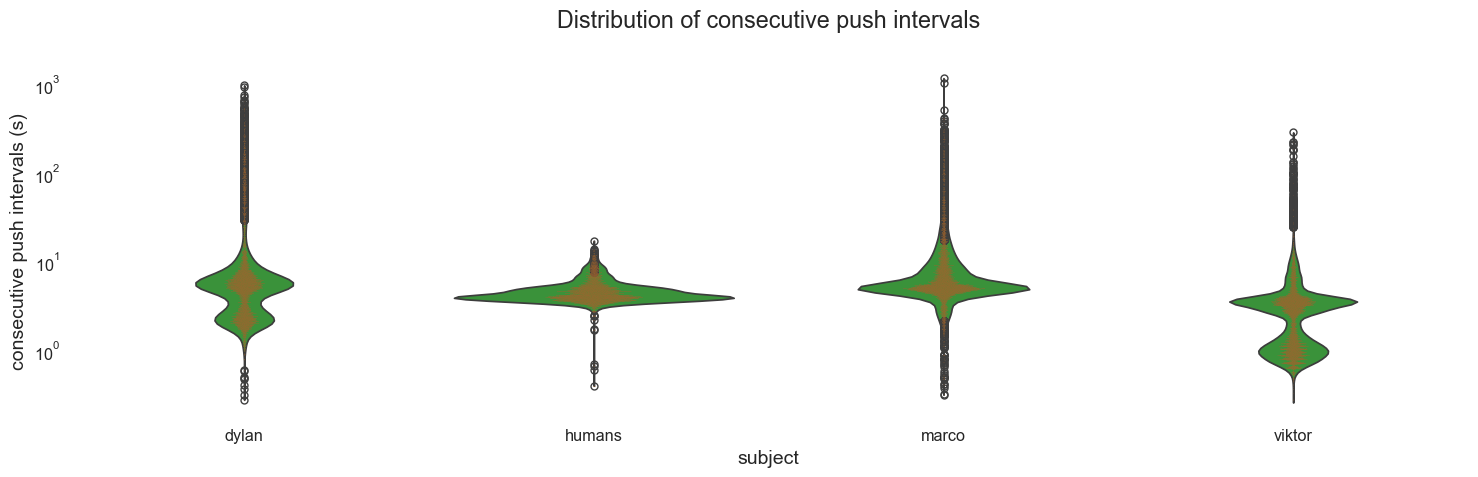

In [7]:
# Plot distribution of push intervals on log-scale
fig, ax = plt.subplots()
bp(sns.boxplot)(df, x='subject', y='consecutive push intervals', showcaps=False,
                showbox=False, log_scale=True, whiskerprops={'visible': False}, medianprops={'visible': False},
                legend=False, ax=ax)
bp(sns.swarmplot)(df.groupby('subject').sample(10000, random_state=SEED, replace=True), x='subject',
                  y='consecutive push intervals', legend=False, log_scale=True, size=0.25, dodge=True, ax=ax)
bp(sns.violinplot)(df, x='subject', y='consecutive push intervals', cut=0,
                   inner=None, log_scale=True, title_prefix="Distribution of consecutive push intervals",
                   y_unit='s', legend=False, ax=ax);

We see a mix of bimodality and unimodality among the subjects. Next, we will sort each push interval by the percentile at which it occurs in each subject's data.

dylan's 92.5% push 33.75299999996787
humans's 99.0% push 10.417100000000005
marco's 95.0% push 26.90300000004936
viktor's 99.9% push 32.09999999997672


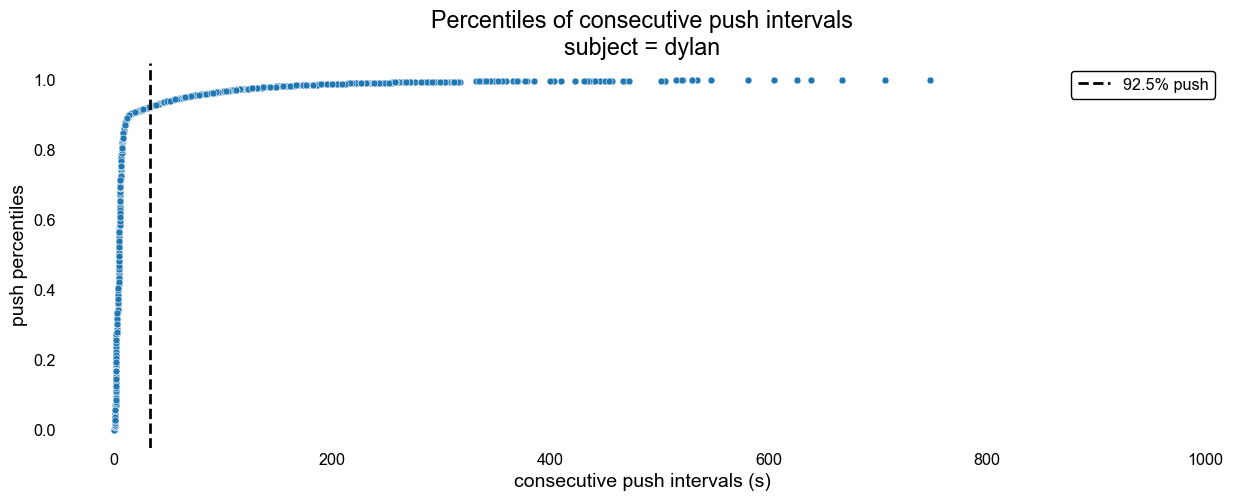

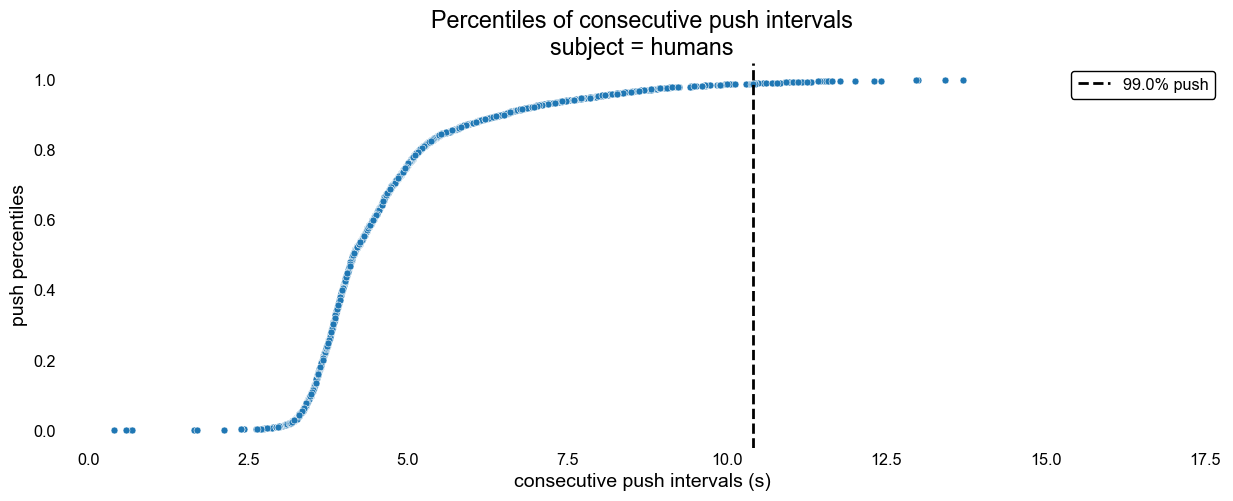

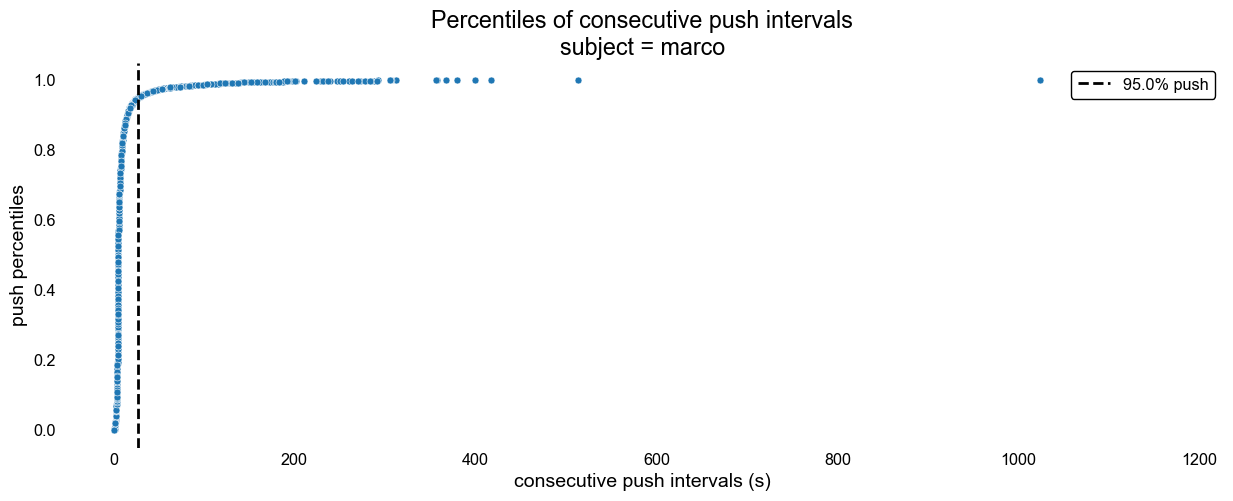

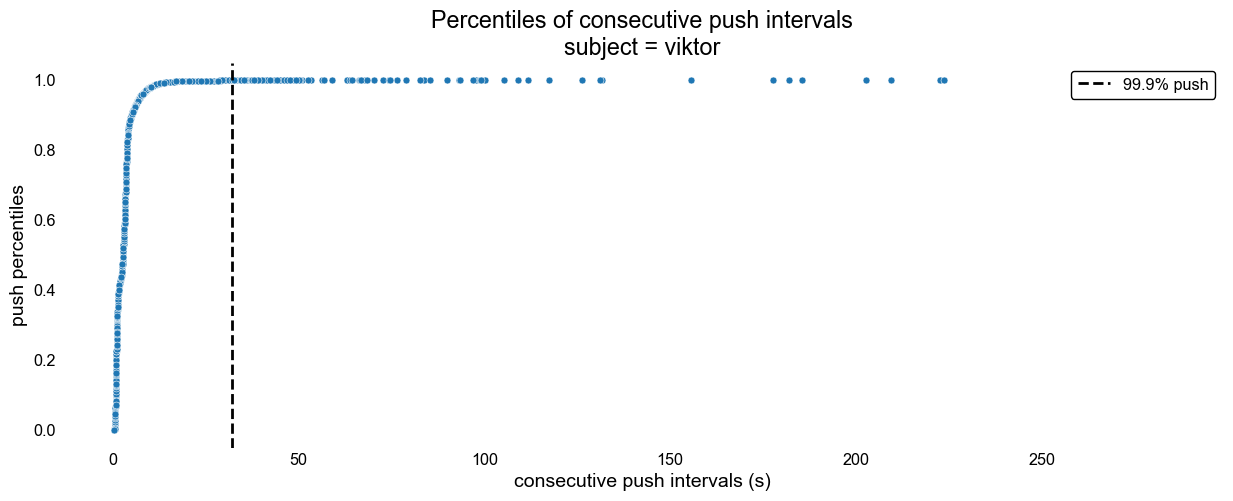

In [8]:
from foraging.plotting.behavior import plot_push_percentiles

df['push percentiles'] = df.groupby('subject', as_index=False)['consecutive push intervals'].rank(pct=True)
subjects = df.index.unique('subject')
percentiles = dict(zip(subjects, [0.925, 0.99, 0.95, 0.999]))
plot_push_percentiles(df, percentiles)

Each subject has different percentiles when push intervals >= 30 s emerge. Throughout the notebook, we will characterize differences between push intervals below and above 30 seconds-- if there are strong qualitative differences, then we can use 30 seconds as a rudimentary boundary between off-task and on-task behavior. Aside from the humans, whose percentile curves are characteristic of a gaussian, the other subjects are heavily non-gaussian. To get a better sense of an appropriate boundary between long push intervals and medium push intervals, we will consider the characteristics of example blocks containing the longest push intervals.

## Example Blocks

Here are the blocks that contain the longest push intervals for each subject. Each push is labeled by its reward outcome, with filled symbols indicating reward and empty no reward, and is colored by the schedule of the box they occur at. Dashed lines connect consecutive pushes.


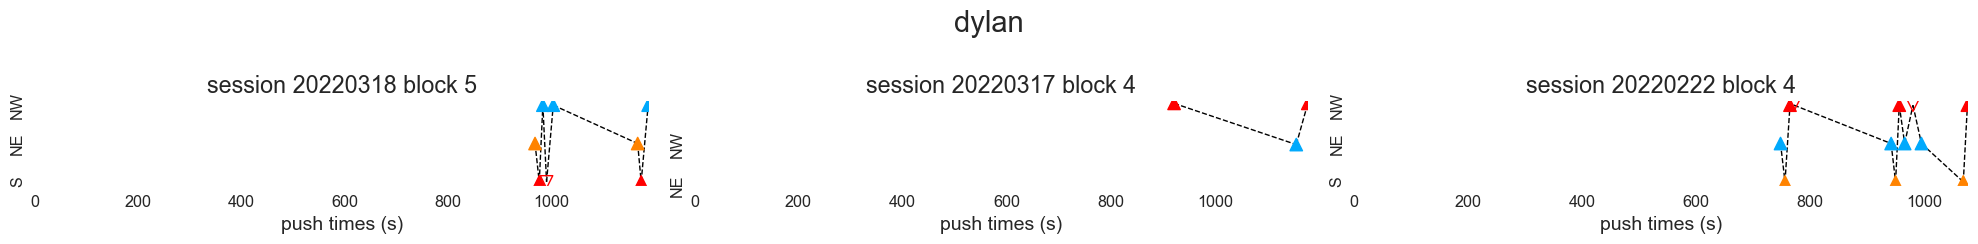

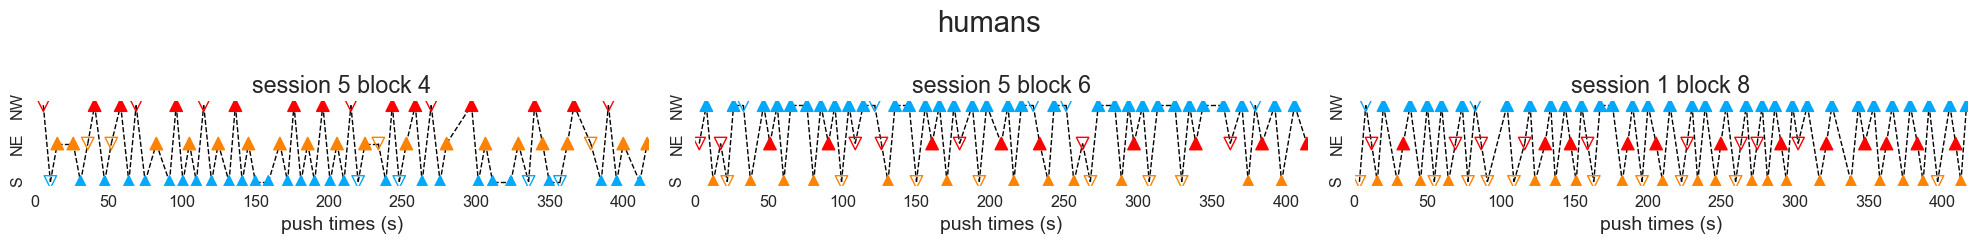

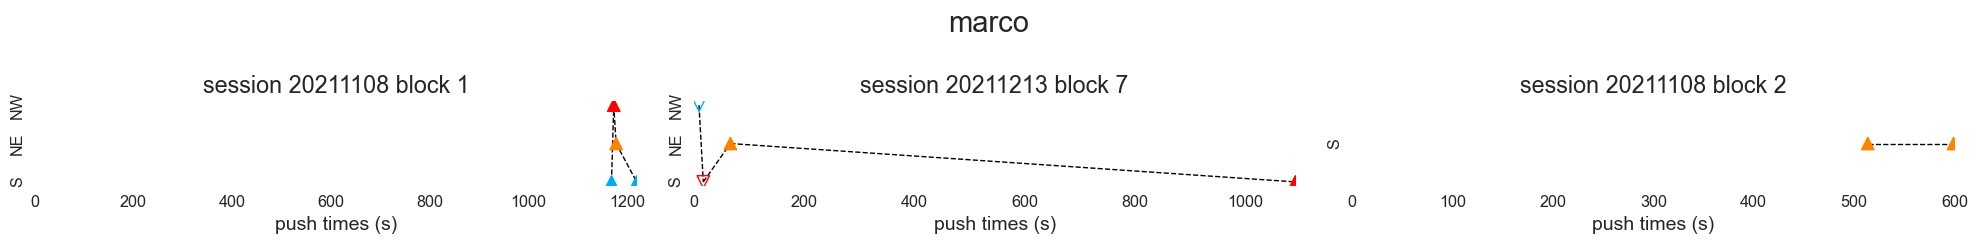

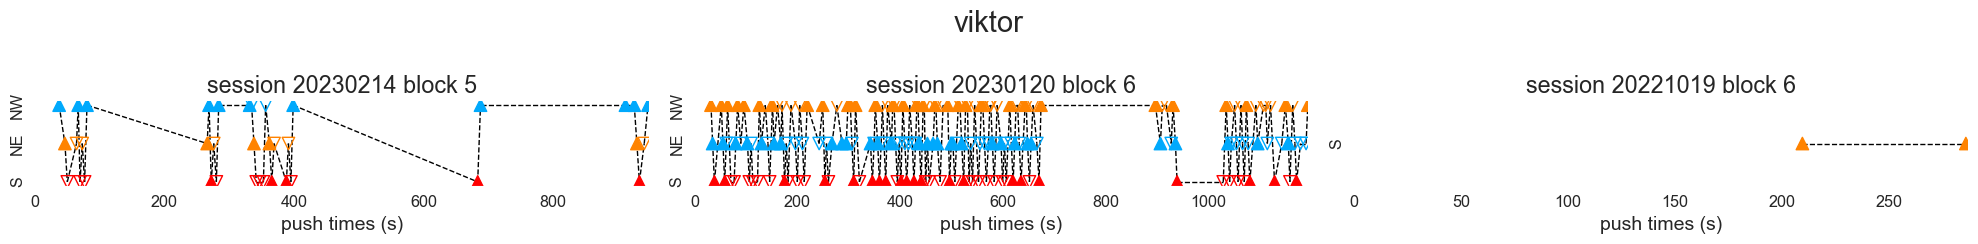

In [16]:
from foraging.plotting.behavior import plot_long_push_blocks

plot_long_push_blocks(df, 3)

Some push intervals appear long because the subject doesn't initiate the task for a long time. We will show the distribution of initiation times next. Also, some blocks are very sparse while other blocks have long segments of task-engaged behavior interrupted by long breaks when the monkey does not push. One consideration for the exclusion criteria is to drop blocks that contain fewer than n pushes e.g. 10 pushes, even if there are a couple "reasonable looking" pushes; it's very likely the animal is actually disengaged the entirety of that block, thus casting doubt on any reasonable behavior appearing in that block. For blocks that are denser in pushes, we need a different criteria.

## Block Initiation

Here we show the distribution of times when the first push in the block occurs for each subject on logscale.



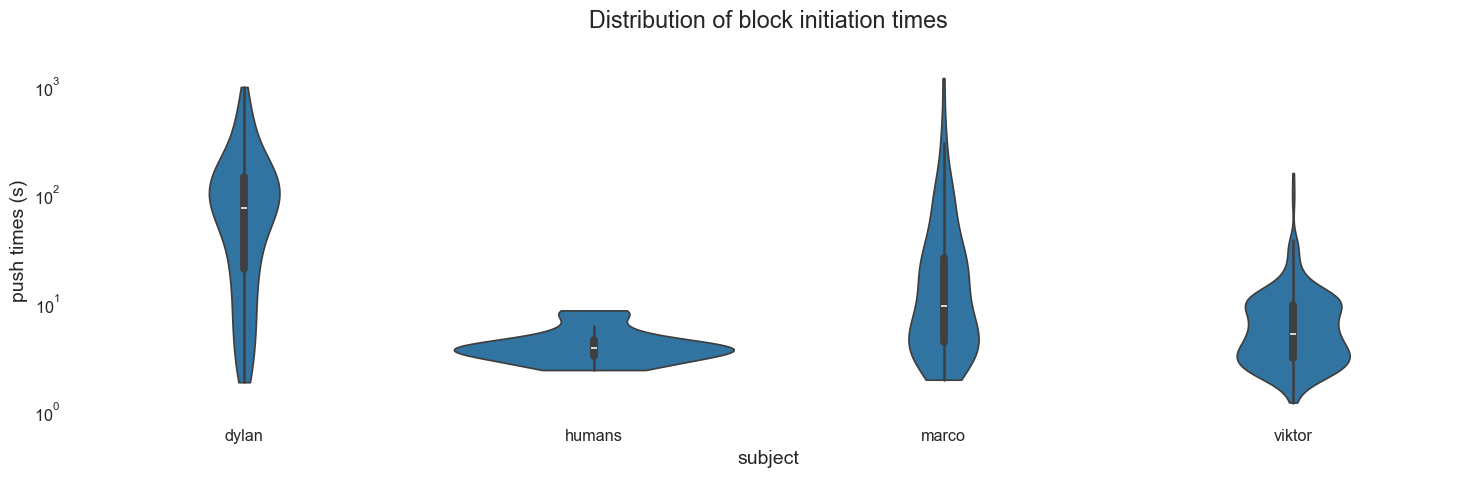

In [10]:
# Plot distribution of push intervals on log-scale
fig, ax = plt.subplots()
df_init = df.xs(1, level='push #')
bp(sns.violinplot)(df_init, x='subject', y='push times', cut=0, log_scale=True,
                   title_prefix="Distribution of block initiation times", y_unit='s', legend=False, ax=ax);

Dylan appears to initiate the block extremely late compared to other subjects, with a mode around 100 s. Marco also seems to have a decent chunk of blocks which are initiated after 100 s. Next, we'll consider possible correlates of long push intervals, such as reward and spatial position.

## Reward

Now we will compare the relationship between reward and lapses for the long push intervals, defined as push intervals >= 30 s, and a control group of medium push intervals sampled from the middle 50% of push intervals for each subject. First, for each push, we will consider the fraction of rewarded pushes in the last 30 seconds preceding the onset of the push interval (which is when the *previous* push occurs), because we are interested in seeing whether satiety up until this point can predict that the next push will be longer than usual. If the reward fraction is particularly high in the long push intervals compared to the control, then it's possible that the subject is satiated and thus more likely to disengage from the task for some time. We will also consider the effect of disappointing outcomes on the likelihood of lapsing-- if, among the unrewarded outcomes prior to the long push intervals, the subject waited longer to push a specific box compared to the medium push intervals and still did not receive reward, then this could be indicative of disappointment playing a role in triggering long push intervals.

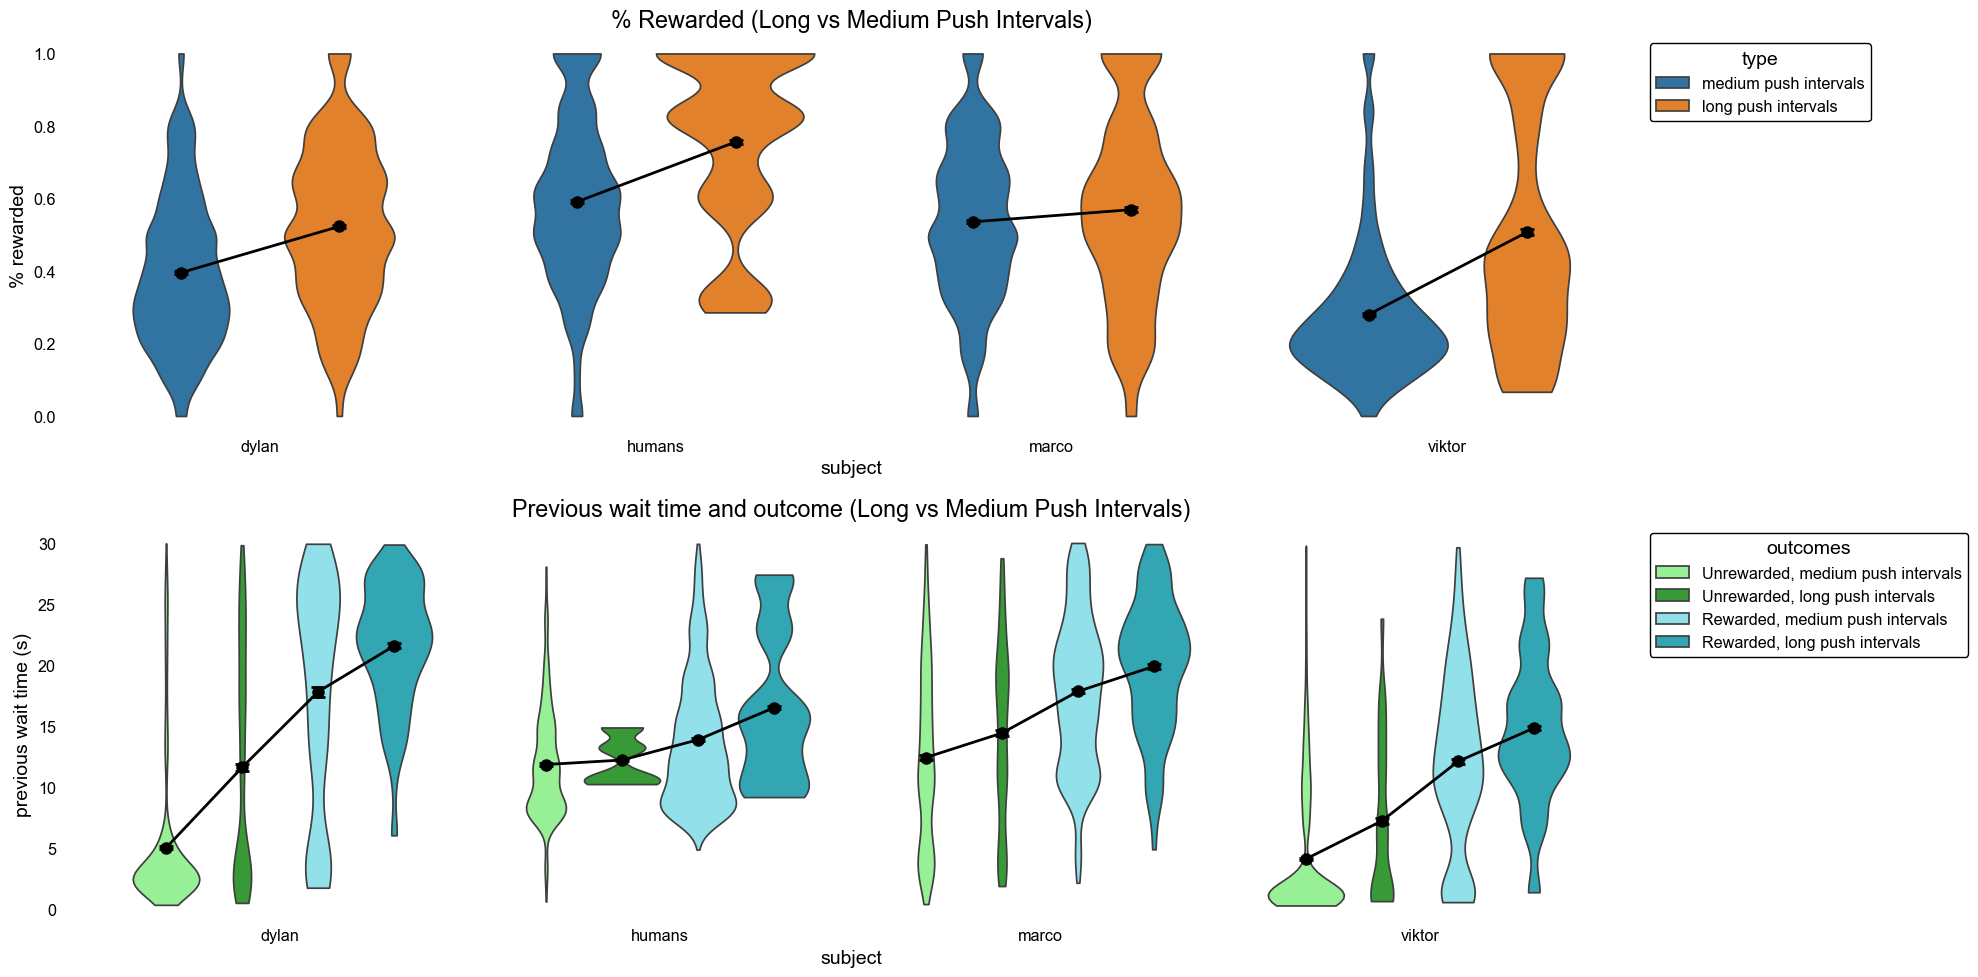

In [25]:
from foraging.plotting.behavior import plot_reward_outcomes_long_vs_medium_pushes

plot_reward_outcomes_long_vs_medium_pushes(df, percentiles)

The long push intervals for most subjects are preceded by a higher fraction of rewarded pushes compared to medium push intervals, suggesting satiety could be a trigger for long push intervals. Also, the unrewarded outcomes preceding the long push intervals are associated with more disappointing outcomes, as the subjects tend to wait longer compared to medium push intervals. The subjects also tend to wait longer before doing a long push interval among rewarded outcomes, which agrees with observing a higher reward fraction since waiting longer leads to a higher reward probability (recall the reward fraction looks at the number of rewarded outcomes in the past 30 seconds preceding the previous push, not necessarily the reward per unit time). This begs the question of whether long push intervals tend to occur close together in time, which is what we will look at next.

## Time

Here, we show the duration of the past 5 push intervals before a long push or medium push to see whether there is a temporal correlation present.

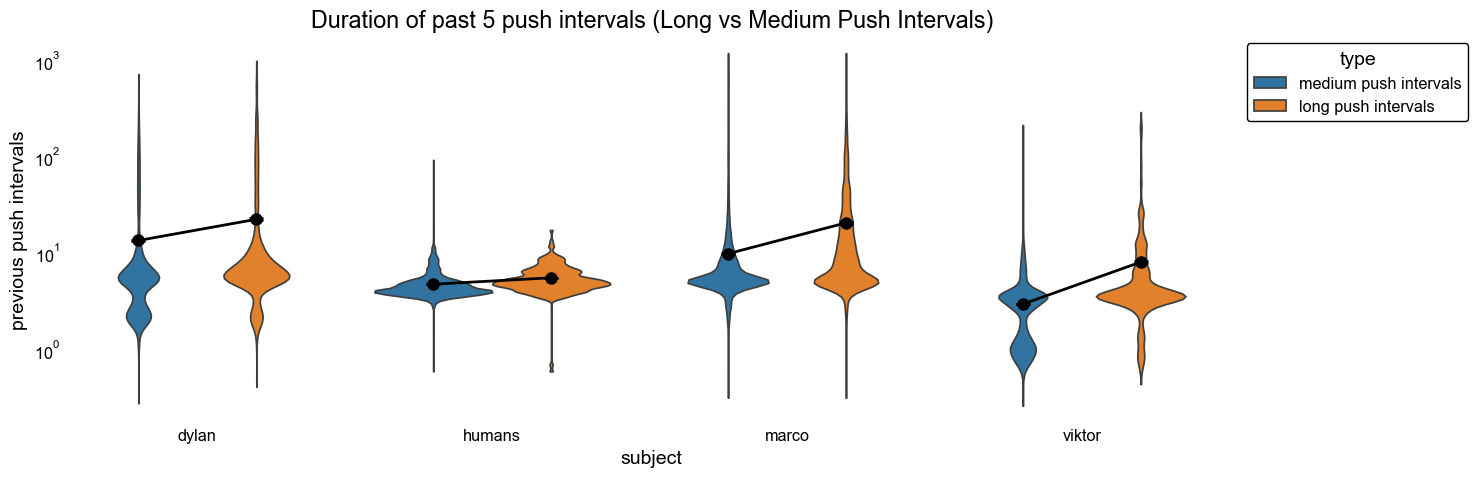

In [11]:
from foraging.plotting.behavior import plot_preceding_pushes_long_vs_medium_pushes

# Get the past 5 pushes and plot their magnitude on Y-axis and current push on X-axis
plot_preceding_pushes_long_vs_medium_pushes(df, percentiles)


Indeed, it appears that for most subjects, the long push intervals tend to be preceeded by longer push intervals than the medium push intervals. Next, we will investigate whether long push intervals tend to occur later in the session, possibly as a result of exhaustion or satiety from engaging with the task for an extended period of time.

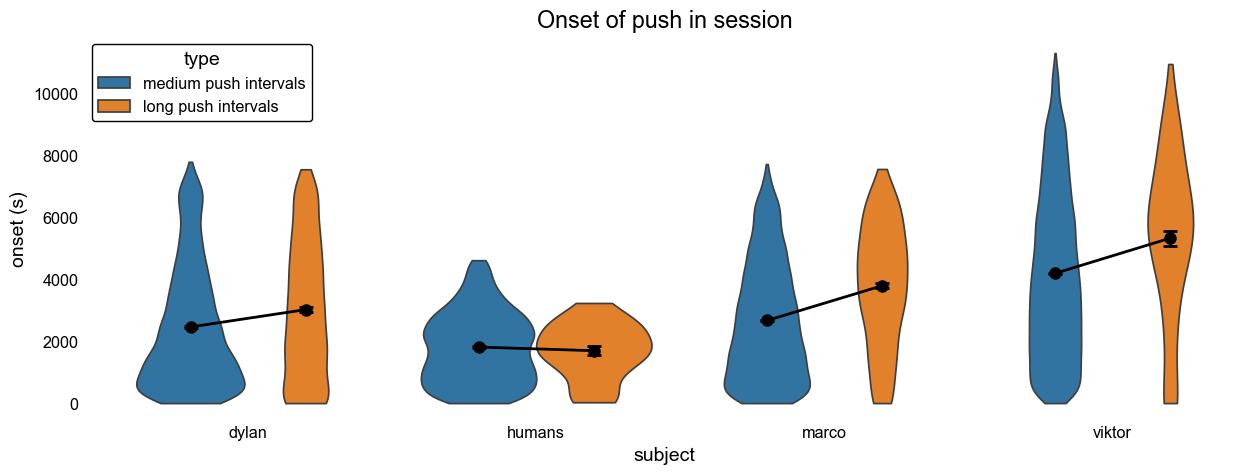

In [9]:
from foraging.plotting.behavior import plot_session_onsets_long_vs_medium_pushes

plot_session_onsets_long_vs_medium_pushes(df, percentiles)

For most subjects, the onsets of the top pushes are greater than the onsets of the middle pushes, suggesting that long push intervals tend to occur later in the session.

## Space
Below is an example block containing a few long push intervals, and the vertical position occupied during push intervals is superimposed on top of the block.

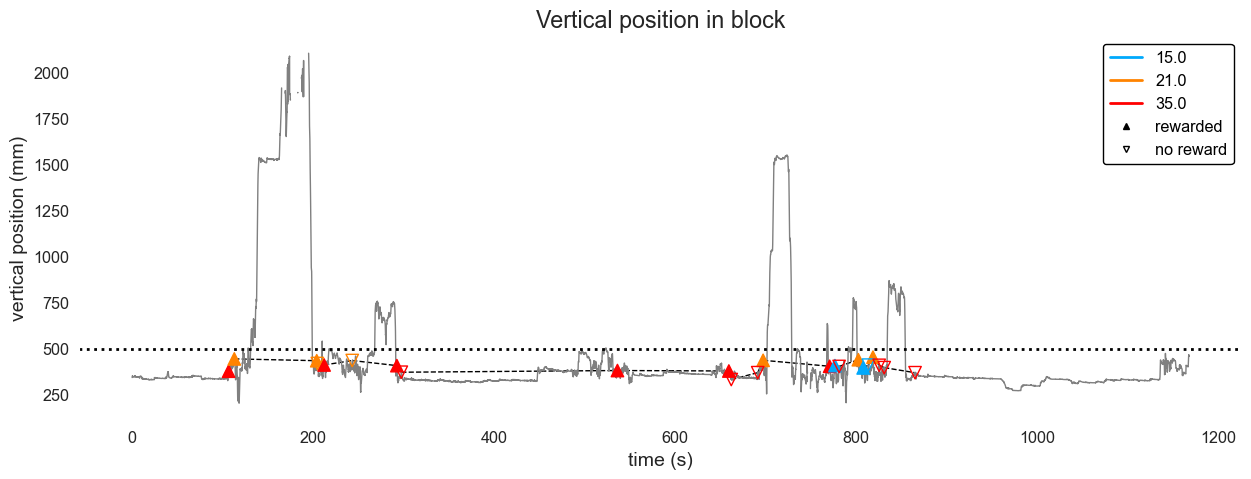

In [23]:
from foraging.plotting.behavior import plot_vertical_position_in_block

conds = {'subject': 'marco', 'session': 20211221, 'block': 6}
plot_vertical_position_in_block(df, conds, EXPERIMENT_DIR)

In this block, there are a couple long push intervals occurring around 100 s and 700 s where the subject climbs up in the arena. There are also long push intervals in the middle of the block where the subject does not climb up but instead stays close to the ground. We will look at the ground positions during long push intervals later. For now, we will aggregate vertical position over multiple blocks, taking the average vertical position occupied during push intervals.

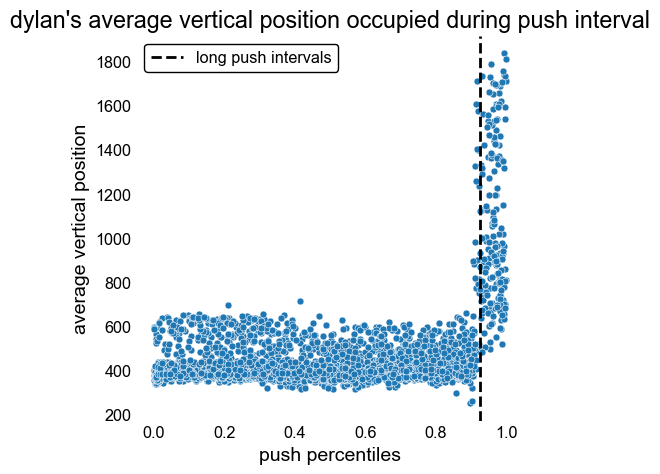

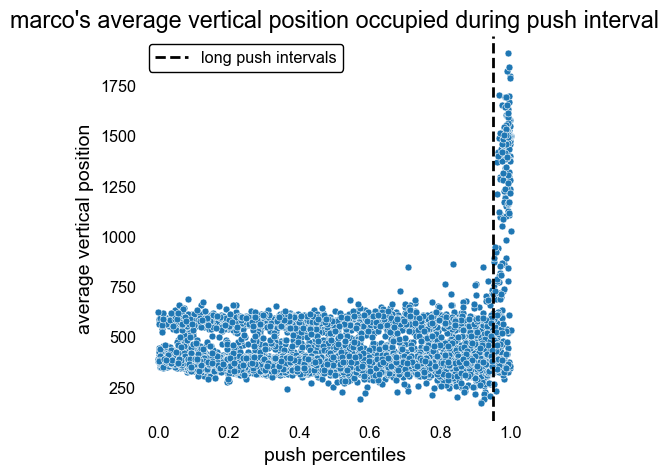

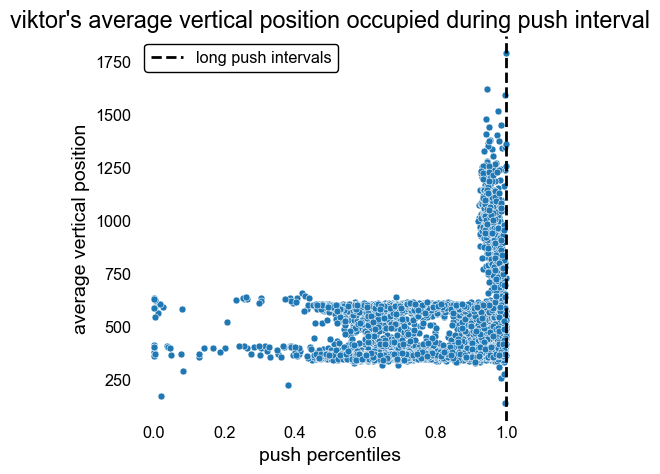

In [26]:
%%capture --no-display
from foraging.plotting.behavior import plot_vertical_position_long_vs_medium_pushes

plot_vertical_position_long_vs_medium_pushes(df, EXPERIMENT_DIR, percentiles=percentiles, figsize=(5, 5))

There is a very strong relationship between vertical position and long push intervals.

## HMM Policy Identification

Dr. Zhe Li has been developing an automatic, data-driven way to identify patterns and clusters in the behavioral data. Fitting an HMM over a diverse set of policies, he has shared the probabilities of 2 policies over time in several blocks of Marco's behavior. Here, we overlay them on top of push intervals in a given block and observe what the HMM is picking out.


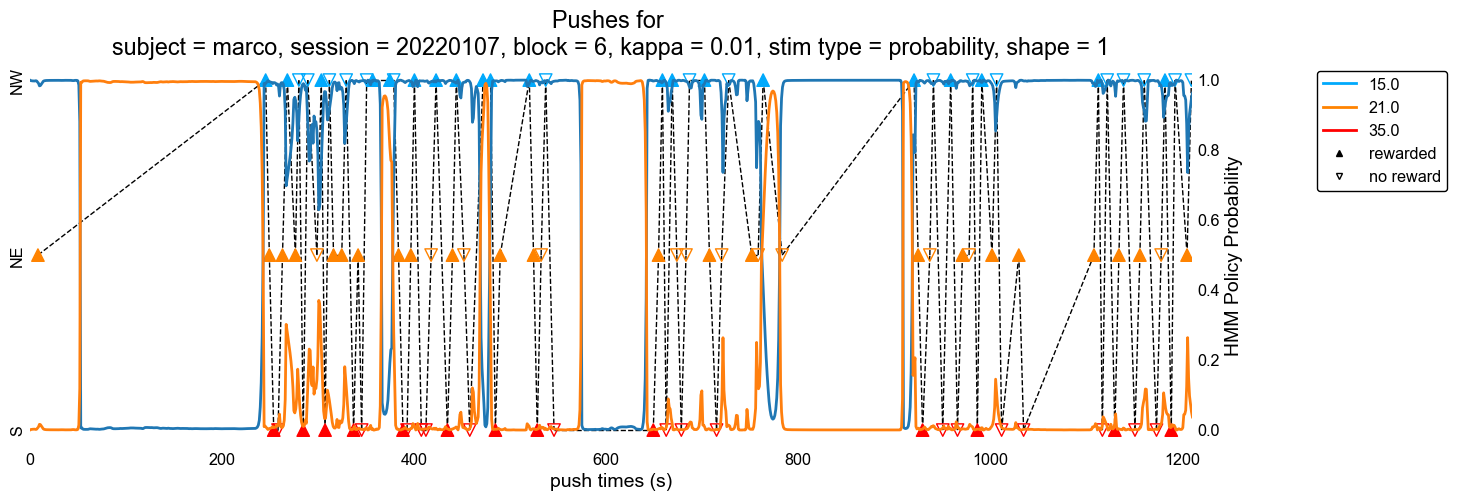

In [22]:
from foraging.plotting.behavior import plot_hmm_probabilities_in_block

plot_hmm_probabilities_in_block(df, os.path.join(EXPERIMENT_DIR, 'HMM.solution_[K2].pkl'))

# Clean Data

To summarize, long push intervals that exceed 30 seconds have the following characteristics:

+ they tend to occur close together in time
+ they tend to be followed by a high reward fraction compared to medium push intervals
+ they tend to occur later in the session compared to medium push intervals
+ they correlate with the subjects' climbing around in the arena

Taking all these observations into account, the following is a preliminary exclusion criteria:

+ remove all blocks with less than 10 pushes
+ remove all blocks where the schedules contain 80 s as one of the boxes
+ remove pushes greater than 30 s when the monkey is not pushing anything

This can be greatly expanded upon and refined through automated methods that we are currently developing. For now, this is a baseline criteria that serves as a starting point for more advanced analysis.

In [16]:
from foraging.utils.data import exclusion_criteria

df_filtered = exclusion_criteria(df)
print(f'Applying exclusion criteria dropped {len(df) - len(df_filtered)} pushes')

Applying exclusion criteria dropped 3017 pushes


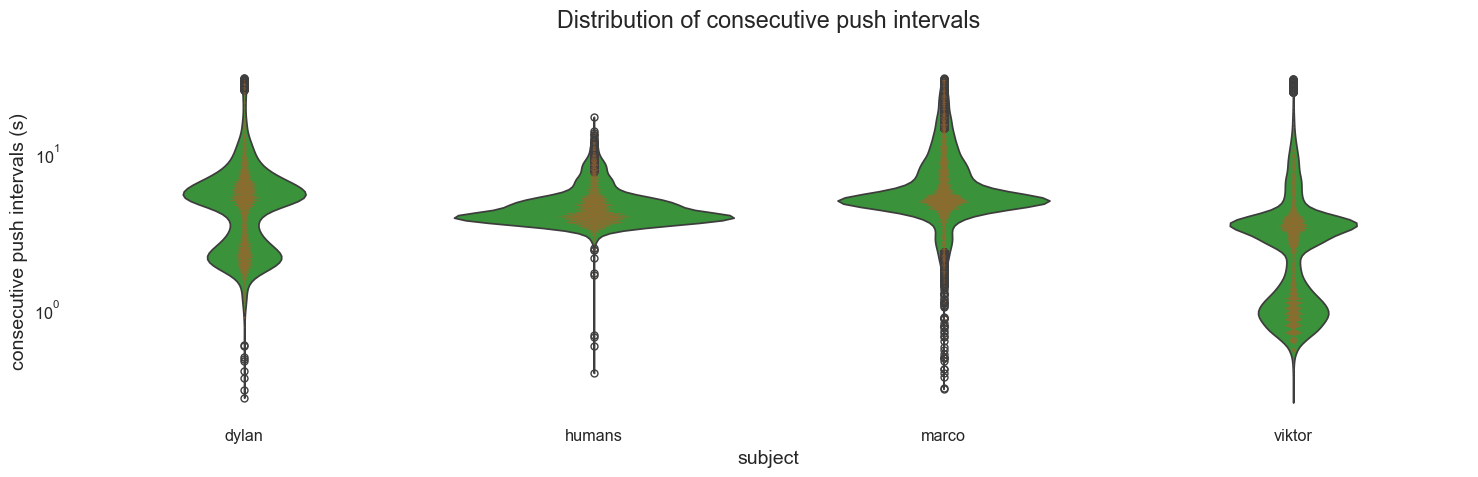

In [17]:
# Plot distribution of push intervals on log-scale
fig, ax = plt.subplots()
bp(sns.boxplot)(df_filtered, x='subject', y='consecutive push intervals', showcaps=False,
                showbox=False, log_scale=True, whiskerprops={'visible': False}, medianprops={'visible': False},
                legend=False, ax=ax)
bp(sns.swarmplot)(df_filtered.groupby('subject').sample(10000, random_state=SEED, replace=True), x='subject',
                  y='consecutive push intervals', legend=False, log_scale=True, size=0.25, dodge=True, ax=ax)
bp(sns.violinplot)(df_filtered, x='subject', y='consecutive push intervals', cut=0,
                   inner=None, log_scale=True, title_prefix="Distribution of consecutive push intervals",
                   y_unit='s', legend=False, ax=ax);

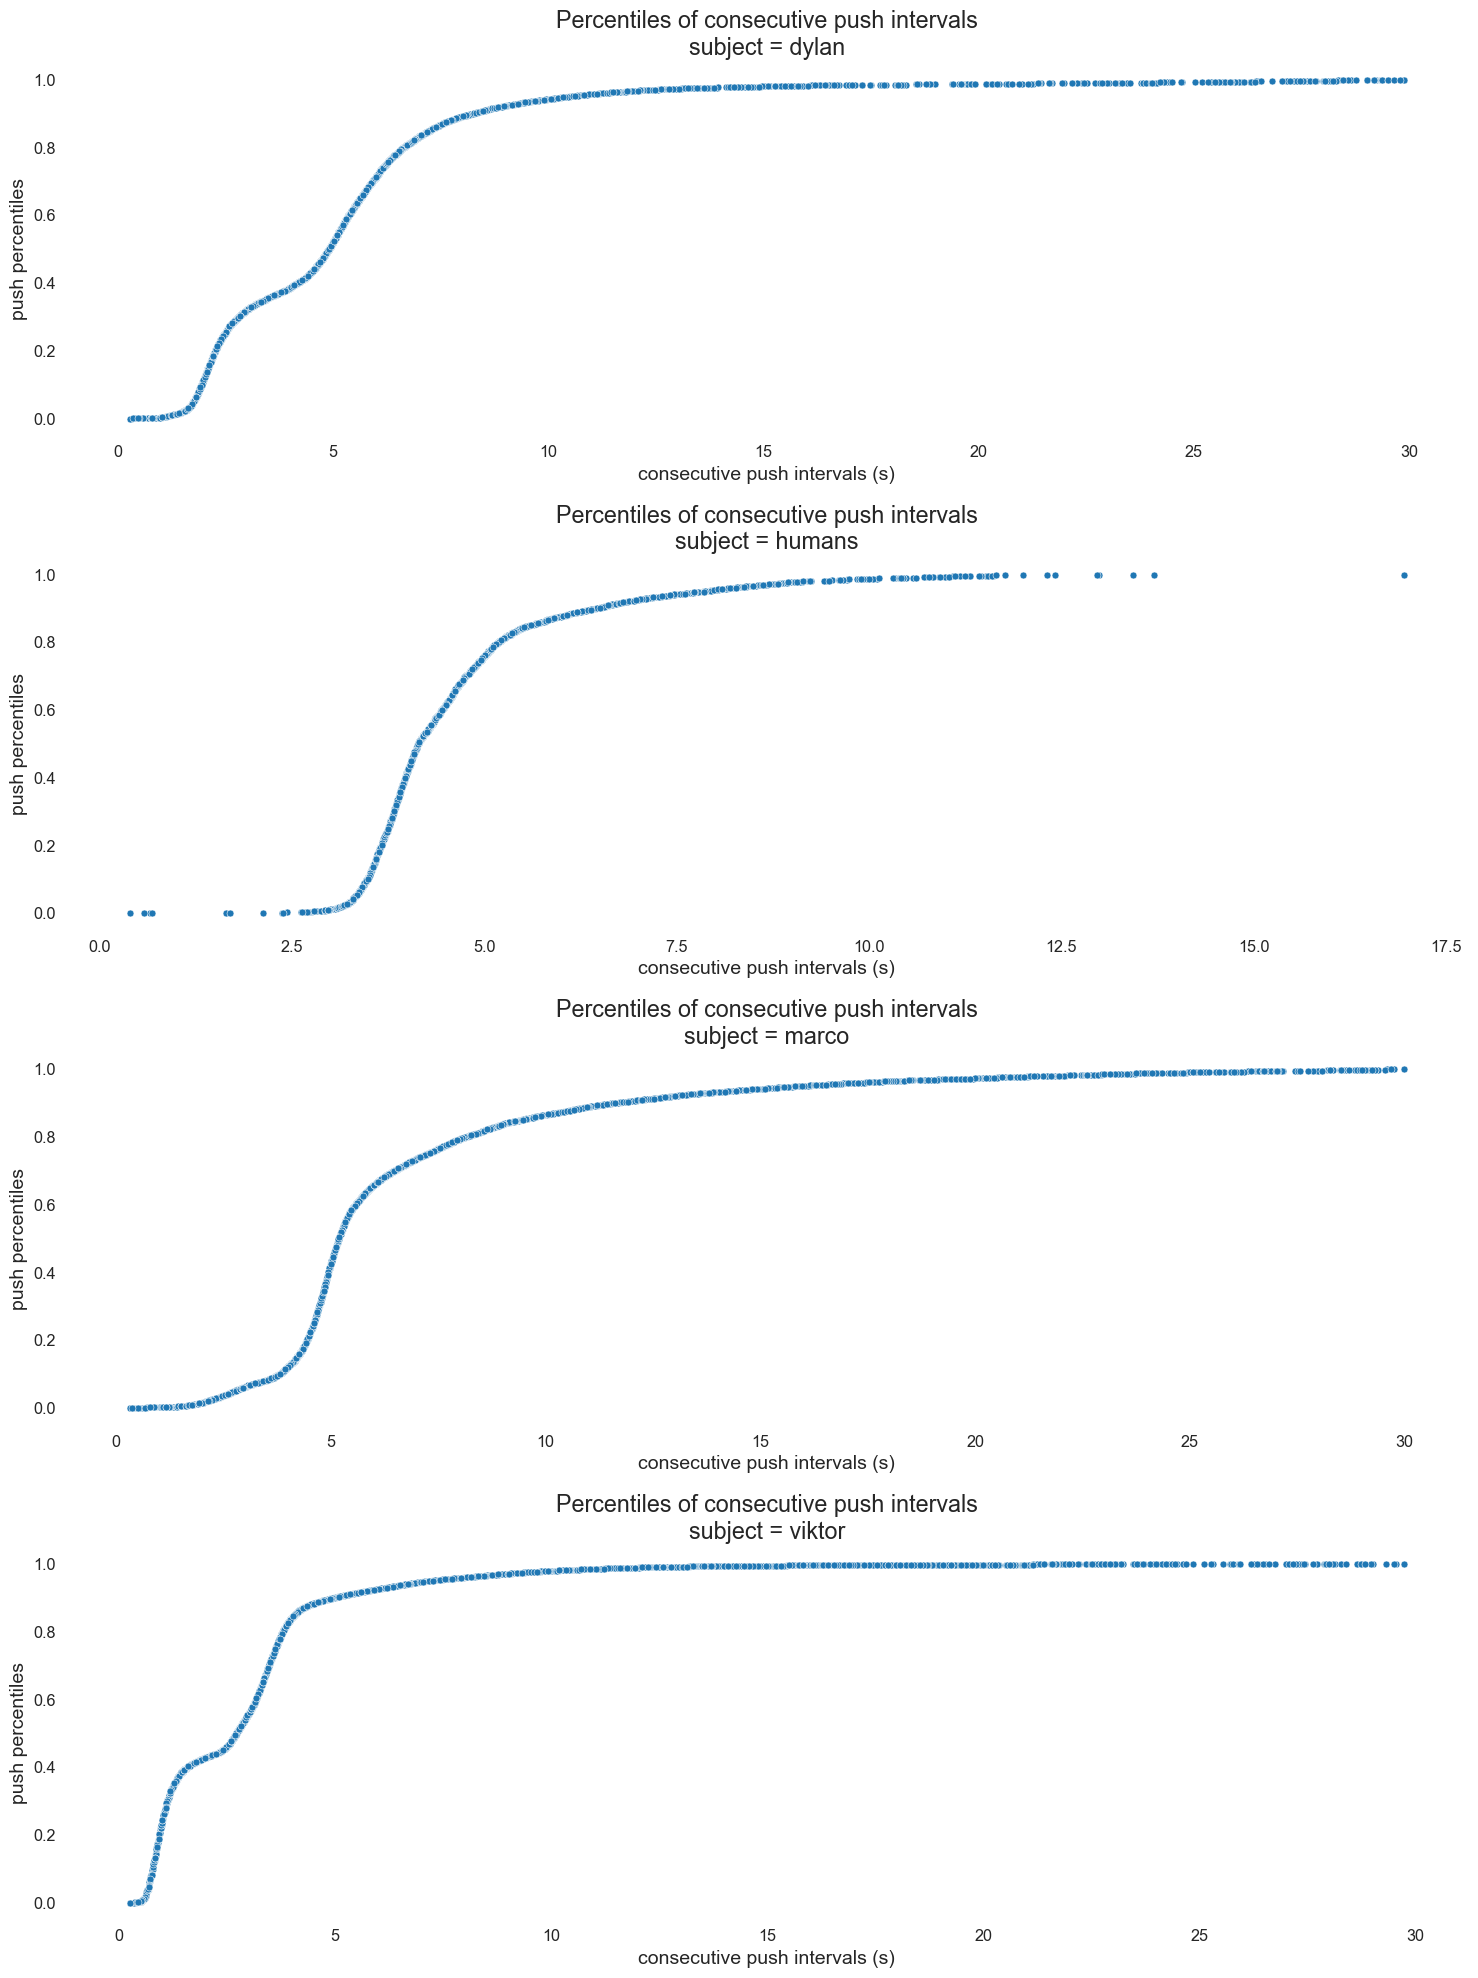

In [46]:
df_filtered['push percentiles'] = df_filtered.groupby('subject', as_index=False)['consecutive push intervals'].rank(
    pct=True)
subjects = df_filtered.index.unique('subject')
fig, axes = plt.subplots(len(subjects), 1, figsize=(15, 20))
for i, subj in enumerate(subjects):
    bp(sns.scatterplot)(df_filtered, x='consecutive push intervals', y='push percentiles', conds={'subject': subj},
                        title_prefix="Percentiles of consecutive push intervals", x_unit='s', ax=axes[i], legend=False)
fig.tight_layout();

Compared to the beginning of this notebook, after removing the outliers for each subject, we see now that the push intervals are within a more reasonable range and behave more like a gaussian.